# Data Exploration Notebook

In [11]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageOps

DATA_DIR = Path("./../data")
SENSORS = ["Accelerometer", "TotalAcceleration", "Gravity", "Gyroscope"] 

FS = 100
TRIM_S = 5  # seconds removed from start and end

FIG_DIR = Path("./../figures")          # exported folder
FIG_DIR.mkdir(exist_ok=True)

## 1. Dataset Loader

In [12]:
def load_dataset(folder: Path) -> dict:
    """Load one recording folder: metadata, sensor CSVs and the location photo."""
    meta = pd.read_csv(folder / "Metadata.csv").iloc[0].to_dict()

    sensors = {}
    for name in SENSORS:
        csv = folder / f"{name}.csv"
        if csv.exists():
            df = pd.read_csv(csv)
            df["t"] = df["seconds_elapsed"]
            sensors[name] = df

    photos = sorted(list(folder.glob("*.jpg")) + list(folder.glob("*.jpeg")) + list(folder.glob("*.png")))
    photo = None
    if photos:
        photo = ImageOps.exif_transpose(Image.open(photos[0]))
        photo.thumbnail((1200, 1200))   #to keep notebook light

    start = pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True).tz_convert(meta["recording timezone"])
    return {
        "name": folder.name,
        "folder": folder,
        "meta": meta,
        "start": start,
        "sensors": sensors,
        "photo": photo,
        "photo_name": photos[0].name if photos else None,
    }

datasets = [load_dataset(d) for d in sorted(DATA_DIR.iterdir()) if d.is_dir()]
print(f"Loaded {len(datasets)} datasets:", [d["name"] for d in datasets])

Loaded 16 datasets: ['P02_B01', 'P02_B02', 'P02_B03', 'P02_B04', 'P02_S01', 'P02_S02', 'P02_S03', 'P02_S04', 'P03_B01', 'P03_B02', 'P03_B03', 'P03_B04', 'P03_S01', 'P03_S02', 'P03_S03', 'P03_S04']


## 2. Data Inventory: 

Each row row represents each measurement.

In [13]:
LABELS = {"B": "bumpy", "S": "smooth"}

def list_recordings(data_dir: Path) -> pd.DataFrame:
    """One row per recording folder named Pxx_Byy / Pxx_Syy: id, participant, label, path, metadata."""
    rows = []
    for rec in sorted(data_dir.iterdir()):                # data/P01_B03
        if not (rec.is_dir() and (rec / "Metadata.csv").exists()):
            continue
        participant, ride = rec.name.split("_")
        meta = pd.read_csv(rec / "Metadata.csv").iloc[0]
        rows.append({
            "recording_id": rec.name,
            "participant": participant,
            "label": LABELS[ride[0]],
            "path": rec,
            "device": meta["device name"],
            "start_time": pd.to_datetime(meta["recording epoch time"], unit="ms", utc=True)
                            .tz_convert(meta["recording timezone"]),
        })
    return pd.DataFrame(rows)


recordings = list_recordings(DATA_DIR)
# print(f"{len(recordings)} recordings")
# print(recordings.groupby(["participant", "label"]).size())
recordings

,recording_id,participant,label,path,device,start_time
0,P02_B01,P02,bumpy,..\data\P02_B01,iPhone 11,2026-09-12 13:49:51.974000+02:00
1,P02_B02,P02,bumpy,..\data\P02_B02,iPhone 11,2026-09-12 13:57:51.246000+02:00
2,P02_B03,P02,bumpy,..\data\P02_B03,iPhone 11,2026-09-12 14:01:18.120000+02:00
3,P02_B04,P02,bumpy,..\data\P02_B04,iPhone 11,2026-09-12 14:04:34.647000+02:00
4,P02_S01,P02,smooth,..\data\P02_S01,iPhone 11,2026-09-08 08:20:20.105000+02:00
5,P02_S02,P02,smooth,..\data\P02_S02,iPhone 11,2026-09-08 17:23:11.157000+02:00
6,P02_S03,P02,smooth,..\data\P02_S03,iPhone 11,2026-09-12 13:46:00.136000+02:00
7,P02_S04,P02,smooth,..\data\P02_S04,iPhone 11,2026-09-12 13:55:01.458000+02:00
8,P03_B01,P03,bumpy,..\data\P03_B01,iPhone 14 Pro,2026-09-10 08:28:45.107000+02:00
9,P03_B02,P03,bumpy,..\data\P03_B02,iPhone 14 Pro,2026-09-10 08:32:05.456000+02:00


## 3. Sampling Consistency analysis

In [14]:
PREFIX = {"Accelerometer": "acc", "TotalAcceleration": "tacc", "Gravity": "grav", "Gyroscope": "gyro"}
TOL_S = 0.005   # max timestamp distance between samples across sensors (= half a sample at 100 Hz)

def load_recording(rec_path: Path, sensors=SENSORS) -> pd.DataFrame:
    """Join the sensor CSVs sample-by-sample on their timestamps. No resampling."""
    out = None
    for name in sensors:
        if not (rec_path / f"{name}.csv").exists():
            continue
        df = pd.read_csv(rec_path / f"{name}.csv")[["seconds_elapsed", "x", "y", "z"]].sort_values("seconds_elapsed")
        df.columns = ["t"] + [f"{PREFIX[name]}_{a}" for a in "xyz"]
        out = df if out is None else pd.merge_asof(out, df, on="t", direction="nearest", tolerance=TOL_S)
    out = out.dropna().reset_index(drop=True)
    if "tacc_x" not in out:                                     
        for a in "xyz":
            out[f"tacc_{a}"] = out[f"acc_{a}"] + out[f"grav_{a}"]
    return out

# load everything once: keep recording_id / participant / label on every row
data = {}
for r in recordings.itertuples():
    df = load_recording(r.path)
    df["recording_id"] = r.recording_id
    df["participant"] = r.participant
    df["label"] = r.label
    data[r.recording_id] = df

n = sum(len(d) for d in data.values())
print(f"Loaded {len(data)} recordings, {n} samples at {FS} Hz ({n / FS / 60:.1f} min)")
pd.DataFrame(
    {k: {"samples": len(v), 
         "median_dt_ms": 1000 * np.median(np.diff(v["t"])), 
         "max_dt_ms": 1000 * np.diff(v["t"]).max()} 
     for k, v in data.items()
    }).T.round(2)

Loaded 16 recordings, 134462 samples at 100 Hz (22.4 min)


,samples,median_dt_ms,max_dt_ms
P02_B01,8033.0,10.03,10.04
P02_B02,7275.0,10.03,10.04
P02_B03,7581.0,10.03,10.04
P02_B04,8015.0,10.03,10.04
P02_S01,13341.0,10.03,10.21
P02_S02,7814.0,10.03,10.03
P02_S03,7967.0,10.03,10.04
P02_S04,8719.0,10.03,10.04
P03_B01,12449.0,10.00,13.13
P03_B02,11206.0,10.00,19.38


## 4. Trim

From initial time plots, and discussions it has been established that the first/last 5 seconds are most of the times for putting away the phone.

In [15]:
def trim(df: pd.DataFrame, trim_s: float = TRIM_S) -> pd.DataFrame:
    t0, t1 = df["t"].iloc[0] + trim_s, df["t"].iloc[-1] - trim_s
    return df[(df["t"] >= t0) & (df["t"] <= t1)].reset_index(drop=True)

trimmed = {k: trim(v) for k, v in data.items()}
durations = pd.DataFrame({
    "raw_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in data.items()},
    "trimmed_s": {k: v["t"].iloc[-1] - v["t"].iloc[0] for k, v in trimmed.items()},
}).round(1)

print(f"Shortest trimmed recording: {durations['trimmed_s'].min()} s ({durations['trimmed_s'].idxmin()})")
durations.T

Shortest trimmed recording: 52.1 s (P03_S03)


,P02_B01,P02_B02,P02_B03,P02_B04,P02_S01,P02_S02,P02_S03,P02_S04,P03_B01,P03_B02,P03_B03,P03_B04,P03_S01,P03_S02,P03_S03,P03_S04
raw_s,80.6,73.0,76.0,80.4,133.8,78.4,79.9,87.5,124.5,112.1,63.7,63.0,86.4,79.1,62.1,66.4
trimmed_s,70.6,63.0,66.0,70.4,123.8,68.4,69.9,77.4,114.5,102.1,53.7,53.0,76.4,69.1,52.1,56.3


## 5. Dataset statistics

One row per recording (after trimming): how much data per class, per participant, per device, and how long the rides are.

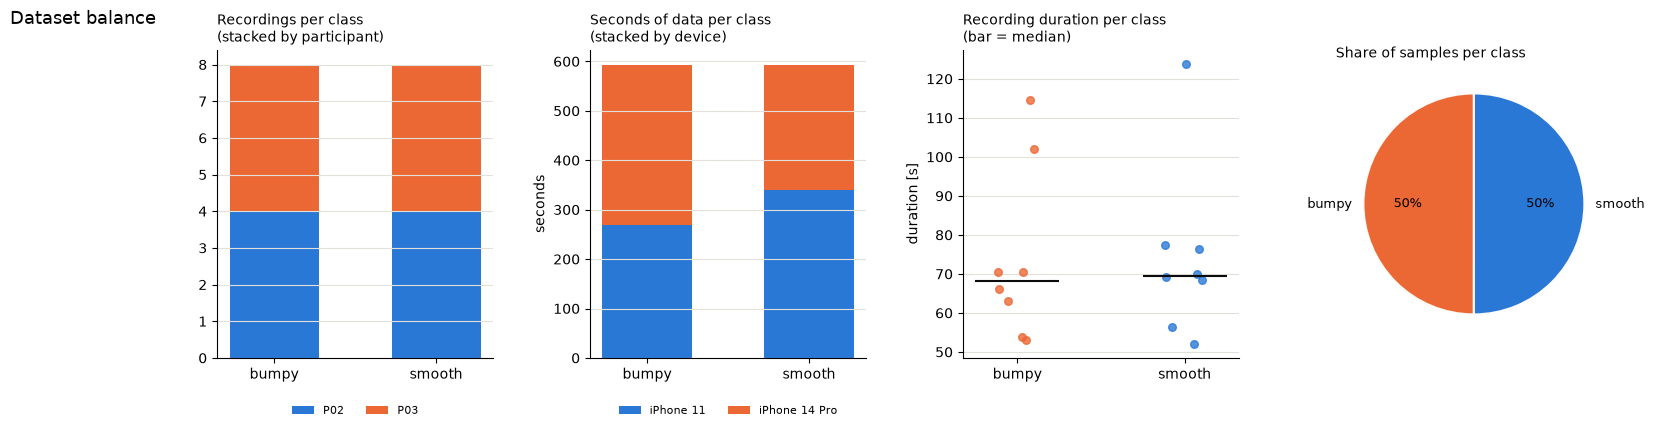

16 recordings, 19.8 min, 118481 samples


recordings  seconds
participant class                      
P02         bumpy            4    270.0
            smooth           4    340.0
P03         bumpy            4    323.0
            smooth           4    254.0

In [16]:
CLASSES = ["bumpy", "smooth"]
UNITS = {"acc": "m/s^2 (gravity removed)", "tacc": "m/s^2", "grav": "m/s^2", "gyro": "rad/s"}

PALETTE = ["#2a78d6", "#eb6834", "#1baf7a"]
AXIS_COLOR = dict(zip("xyz", PALETTE))
CLASS_COLOR = {"bumpy": "#eb6834", "smooth": "#2a78d6"}

plt.rcParams.update({"axes.grid": True, "grid.color": "#e1e0d9", "axes.spines.top": False, "axes.spines.right": False,
                     "lines.linewidth": 1.0, "figure.dpi": 100})

summary = pd.DataFrame([{
    "recording_id": k, "class": v["label"].iloc[0], "participant": v["participant"].iloc[0],
    "device": recordings.set_index("recording_id").loc[k, "device"],
    "duration_s": v["t"].iloc[-1] - v["t"].iloc[0], "samples": len(v),
} for k, v in trimmed.items()])

fig, axes = plt.subplots(1, 4, figsize=(18, 4), gridspec_kw={"wspace": 0.35})

# (a) recordings per class, stacked by participant
ct = pd.crosstab(summary["class"], summary["participant"]).reindex(CLASSES)
part_colors = {p: PALETTE[i % len(PALETTE)] for i, p in enumerate(sorted(summary["participant"].unique()))}
bottom = np.zeros(len(ct))
for p in ct.columns:
    axes[0].bar(ct.index, ct[p], bottom=bottom, color=part_colors[p], label=p, width=0.55)
    bottom += ct[p].values
axes[0].set_title("Recordings per class\n(stacked by participant)", loc="left", fontsize=10)
axes[0].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=3)
axes[0].grid(axis="x", visible=False)

# (b) seconds per class, stacked by device
ct = pd.crosstab(summary["class"], summary["device"], values=summary["duration_s"], aggfunc="sum").fillna(0).reindex(CLASSES)
dev_colors = {dv: PALETTE[i % len(PALETTE)] for i, dv in enumerate(sorted(summary["device"].unique()))}
bottom = np.zeros(len(ct))
for dv in ct.columns:
    axes[1].bar(ct.index, ct[dv], bottom=bottom, color=dev_colors[dv], label=dv, width=0.55)
    bottom += ct[dv].values
axes[1].set_title("Seconds of data per class\n(stacked by device)", loc="left", fontsize=10)
axes[1].set_ylabel("seconds")
axes[1].legend(frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
axes[1].grid(axis="x", visible=False)

# (c) duration distribution per class
rng = np.random.default_rng(0)
for i, cls in enumerate(CLASSES):
    dur = summary.loc[summary["class"] == cls, "duration_s"]
    axes[2].scatter(np.full(len(dur), i) + rng.uniform(-0.12, 0.12, len(dur)), dur,
                    color=CLASS_COLOR[cls], alpha=0.8, s=30, zorder=3)
    axes[2].hlines(dur.median(), i - 0.25, i + 0.25, color="#0b0b0b", lw=1.5, zorder=4)
axes[2].set_xticks(range(len(CLASSES)), CLASSES)
axes[2].set_ylabel("duration [s]")
axes[2].set_title("Recording duration per class\n(bar = median)", loc="left", fontsize=10)
axes[2].grid(axis="x", visible=False)

# (d) share of samples per class
samples = summary.groupby("class")["samples"].sum().reindex(CLASSES)
axes[3].pie(samples, labels=samples.index, colors=[CLASS_COLOR[c] for c in samples.index],
            autopct="%1.0f%%", startangle=90, wedgeprops={"linewidth": 1.5, "edgecolor": "#fcfcfb"},
            textprops={"fontsize": 9})
axes[3].set_title("Share of samples per class", loc="left", fontsize=10)
axes[3].grid(False)

fig.suptitle("Dataset balance", fontsize=13, x=0.01, ha="left")
fig.savefig(FIG_DIR / "dataset_balance.png", dpi=120, bbox_inches="tight")
plt.show()

print(f"{len(summary)} recordings, {summary['duration_s'].sum() / 60:.1f} min, {summary['samples'].sum()} samples")
summary.groupby(["participant", "class"]).agg(recordings=("recording_id", "count"), seconds=("duration_s", "sum")).round(0)

## 6. Time Series Visualization

Plot selected/typed measurement: one subplot per sensor, x/y/z in fixed colours.

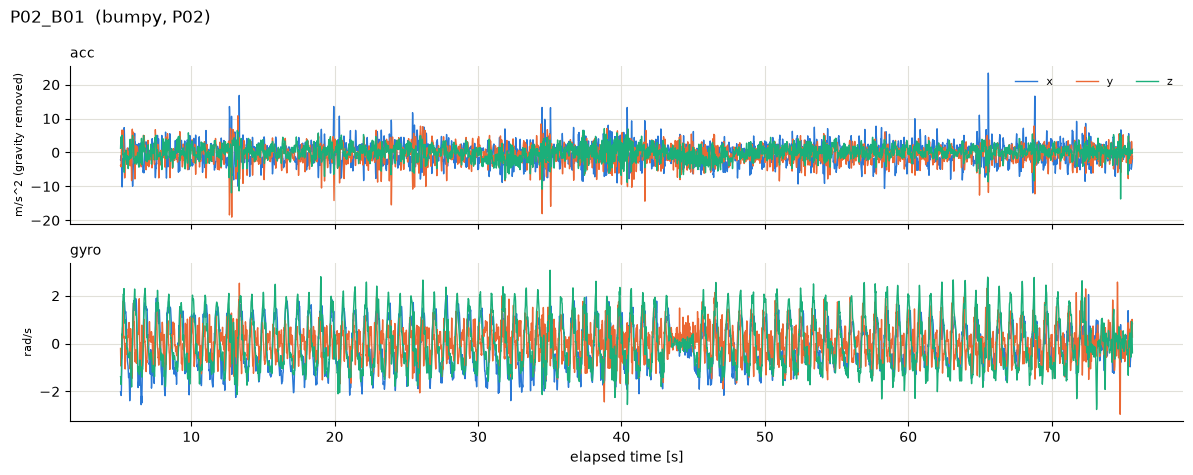

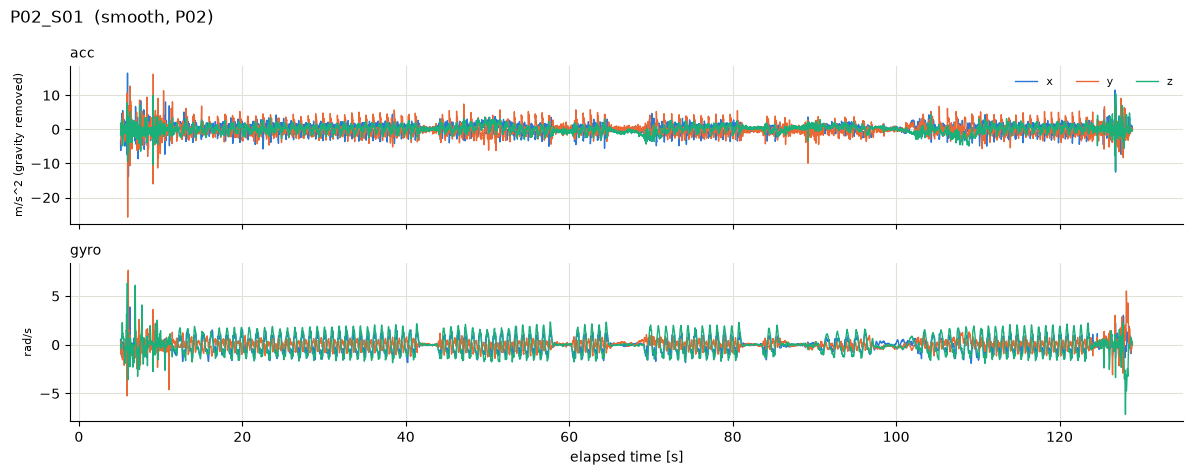

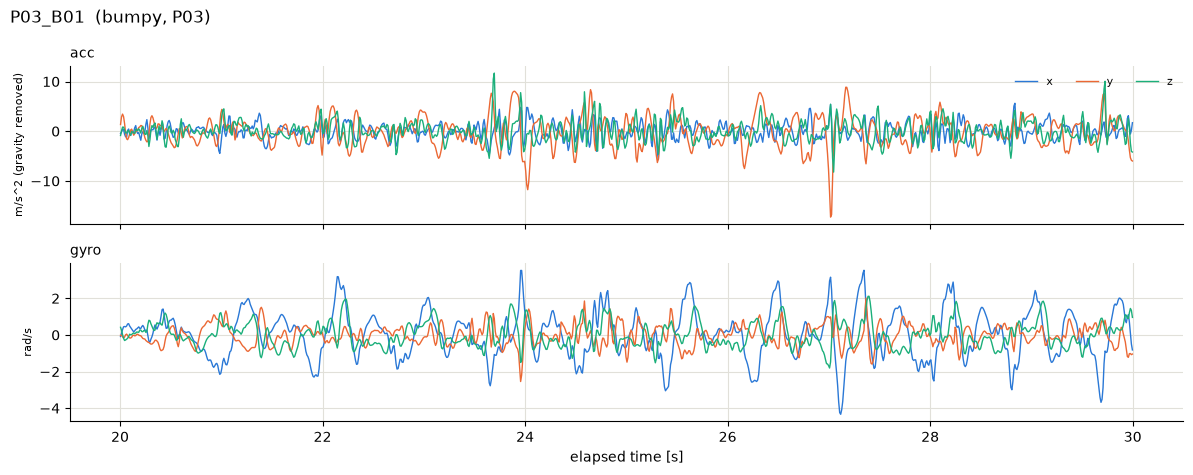

In [ ]:
def plot_recording(df: pd.DataFrame, sensors=("acc", "gyro"), t_start=None, t_end=None, save=False):
    rec = df["recording_id"].iloc[0]
    if t_start is not None or t_end is not None:
        df = df[(df["t"] >= (t_start or -np.inf)) & (df["t"] <= (t_end or np.inf))]

    fig, axes = plt.subplots(len(sensors), 1, figsize=(12, 2.4 * len(sensors)), sharex=True, squeeze=False)
    for ax, s in zip(axes[:, 0], sensors):
        for a in "xyz":
            ax.plot(df["t"], df[f"{s}_{a}"], color=AXIS_COLOR[a], label=a)
        ax.set_ylabel(UNITS[s], fontsize=8)
        ax.set_title(s, loc="left", fontsize=10)
    axes[0, 0].legend(loc="upper right", ncol=3, frameon=False, fontsize=8)
    axes[-1, 0].set_xlabel("elapsed time [s]")
    fig.suptitle(f"{rec}  ({df['label'].iloc[0]}, {df['participant'].iloc[0]})", x=0.01, ha="left", fontsize=12)
    fig.tight_layout()
    if save:
        fig.savefig(FIG_DIR / f"{rec}.png", bbox_inches="tight")
    plt.show()

plot_recording(trimmed["P02_B01"])
plot_recording(trimmed["P02_S01"])
plot_recording(trimmed["P03_B01"], t_start=20, t_end=30)   # zoom on 10 s

## 7. Normalization 

The phone can be mounted differently in every ride, since we did not explicitly specify in the data collection protocol precisely. Therefore x,y,z have different interpretation per recording, therefore we normalize (or convert) into a orientation invariant equivalent. 

Consider: 
- `acc_mag`   = abs(acc)
- `acc_vert`  = acc projected on the gravity direction (up/down: the road-roughness signal)
- `acc_horiz` = the remaining horizontal part
- `gyro_mag`  = abs(gyro)
- `tacc_mag`  = abs(TotalAcceleration), {gravity + vibration in one number: after mean removal ~ `acc_vert`}



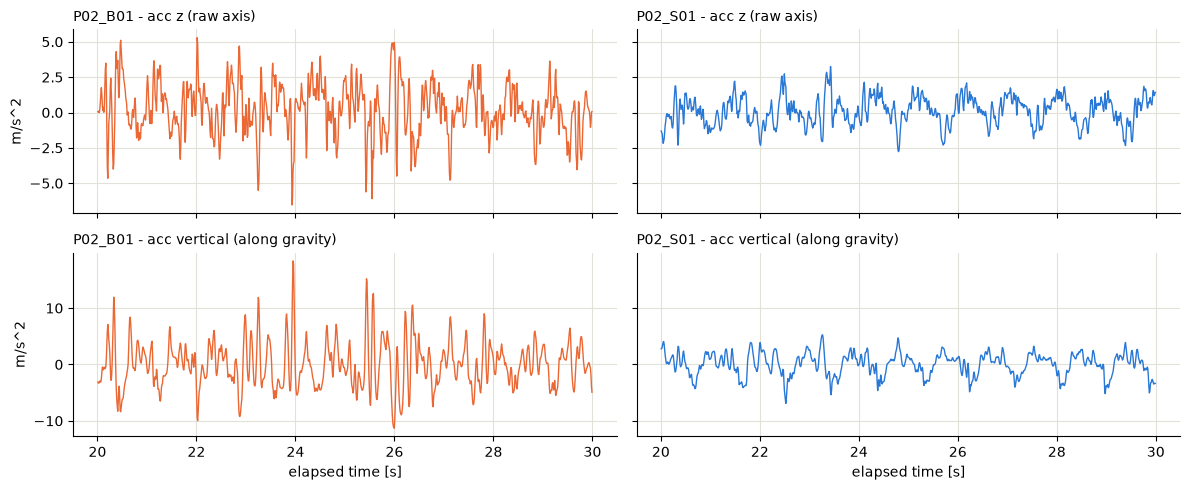

In [ ]:
def add_channels(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    g = df[["grav_x", "grav_y", "grav_z"]].to_numpy()
    g = g / np.linalg.norm(g, axis=1, keepdims=True)      # Euclidean norm: unit "down" vector per sample
    
    a = df[["acc_x", "acc_y", "acc_z"]].to_numpy()
    df["acc_mag"] = np.linalg.norm(a, axis=1)             # Euclidean norm: Total intensity of movement 
    
    # Vertical acceleration isolation
    df["acc_vertical"] = (a * g).sum(axis=1)              # Dot-product: projection
    
    # Horizontal acceleration isolation
    df["acc_horizontal"] = np.sqrt(np.clip(df["acc_mag"] ** 2 - df["acc_vertical"] ** 2, 0, None)) # Pythagoras theorem
    
    df["gyro_mag"] = np.linalg.norm(df[["gyro_x", "gyro_y", "gyro_z"]].to_numpy(), axis=1)
    df["tacc_mag"] = np.linalg.norm(df[["tacc_x", "tacc_y", "tacc_z"]].to_numpy(), axis=1)
    return df

trimmed = {k: add_channels(v) for k, v in trimmed.items()}

# raw axis vs. orientation-free channel: one bumpy and one smooth ride
fig, axes = plt.subplots(2, 2, figsize=(12, 5), sharex="col", sharey="row")

for col, rec in enumerate(["P02_B01", "P02_S01"]):
    d = trimmed[rec]; d = d[(d["t"] >= 20) & (d["t"] <= 30)]
    c = CLASS_COLOR[d["label"].iloc[0]]
    
    axes[0, col].plot(d["t"], d["acc_z"], color=c);    axes[0, col].set_title(f"{rec} - acc z (raw axis)", loc="left", fontsize=10)
    axes[1, col].plot(d["t"], d["acc_vertical"], color=c); axes[1, col].set_title(f"{rec} - acc vertical (along gravity)", loc="left", fontsize=10)
    axes[1, col].set_xlabel("elapsed time [s]")
    
axes[0, 0].set_ylabel("m/s^2"); axes[1, 0].set_ylabel("m/s^2")
fig.tight_layout(); plt.show()

## 8. Frequency Filtering

## 9. Windowing

Maybe also some filtering, like moving average ?